# MSE Loss Training

Trains AdEx parameters on a single experimental trace using direct voltage MSE loss.
Demonstrates the baseline approach and its known failure mode (converging to non-spiking solutions).

In [ ]:
import logging

import jax
import jax.numpy as jnp
import numpy as np
from jax import config

from ADoptEX.core.data import crop_to_stim_window, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, PARAM_BOUNDS, NAUD_PARAMETERS
from ADoptEX.core.simulation import simulate_jaxley
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    make_guarino_loss_fn,
    GuarinoFeatures,
    extract_experimental_features,
    guarino_loss,
    GuarinoLossConfig,
)
from ADoptEX.loss.mse import MSELossConfig, make_mse_loss_fn
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_history_plot,
)
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

## 1. Load Data

In [2]:
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

trace = load_trace(
    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_553.dat",
    current_path=DATA_DIR + "ECBL_IDthresh_ch4_553.dat",
)


print(
    f"Loaded trace: {trace.n_samples} samples, dt={trace.dt_ms:.3f} ms, duration={trace.duration_ms:.1f} ms"
)
print(
    f"Stim window: {trace.stim_start_idx} - {trace.stim_end_idx} ({trace.stim_duration_ms:.1f} ms)"
)
print(f"Stim current: {trace.stim_current_pA:.1f} pA")
print(f"Detected spikes: {trace.n_spikes}")

Loaded trace: 30000 samples, dt=0.100 ms, duration=2999.9 ms
Stim window: 7001 - 27001 (2000.0 ms)
Stim current: 421.3 pA
Detected spikes: 46


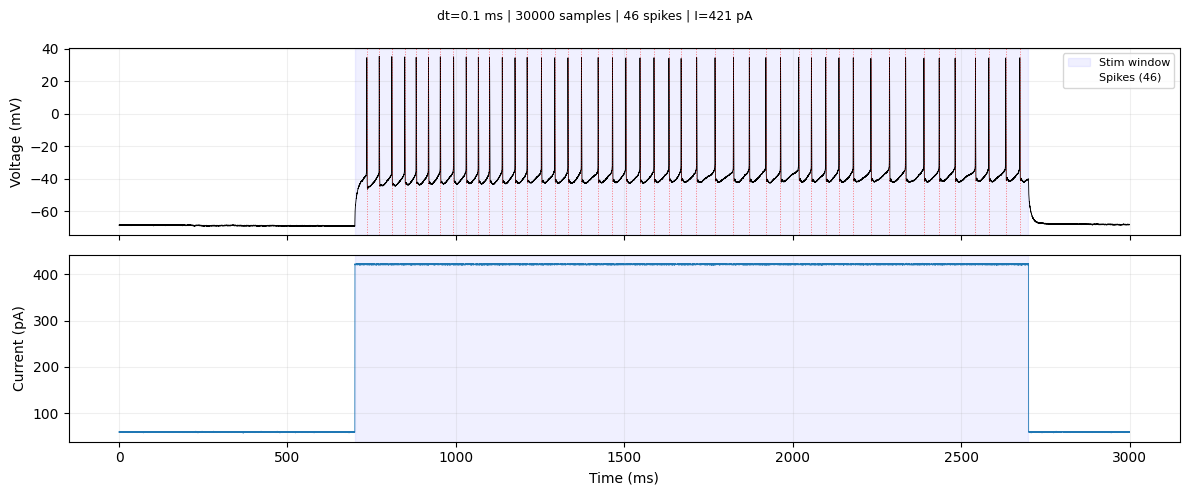

In [3]:
trace_plot(trace);

Cropped trace: 5000 samples, 500.0 ms
Spikes in window: 13 at [ 35.   72.  109.3 147.6 181.6 218.1 253.3 292.8 330.2 366.2 399.5 437.2
 475.1] ms


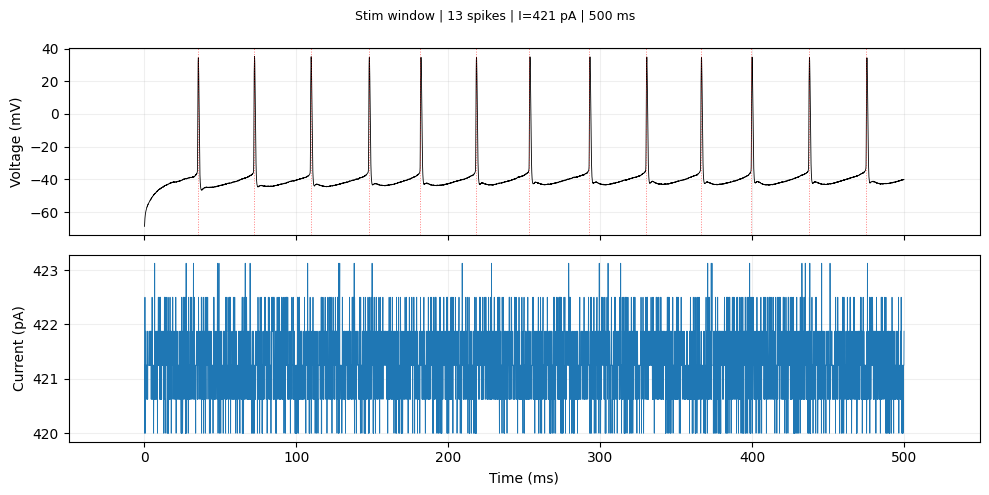

In [4]:
# Crop to stimulation window (500 ms max)
data = crop_to_stim_window(trace, max_duration_ms=500.0)

print(f"Cropped trace: {data.n_samples} samples, {data.stim_duration_ms:.1f} ms")
print(f"Spikes in window: {data.n_spikes} at {data.spike_times.round(1)} ms")

trace_stim_window_plot(data);

## 2. Initial Simulation

Run a forward simulation with default parameters to check that the setup works before training.

INFO:2026-03-03 21:57:29,732:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Initial simulation: 10 spikes, firing rate 16.7 Hz
Experimental:       13 spikes


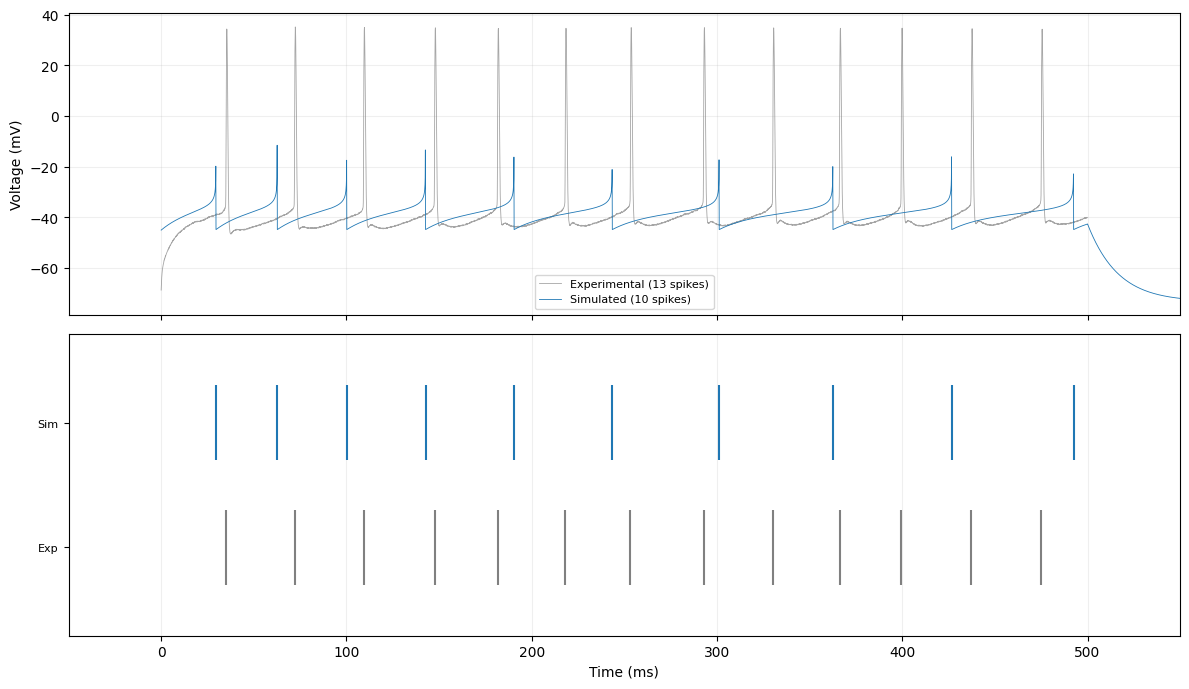

In [5]:
# initial_params = dict(DEFAULT_PARAMS)
initial_params = dict(NAUD_PARAMETERS["adaptation"])
initial_params["v_threshold"] = 0.0  # required by create_adex_cell
initial_params["a"] = -0.0
initial_params["b"] = 10.0

# initial_params["g_L"] =
# initial_params["C_m"] =
# initial_params["E_L"] =
initial_params["v_reset"] = -45
initial_params["v_T"] = -38

# Run forward simulation with step current matching experimental stim
sim_init = simulate_jaxley(
    params=initial_params,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(
    f"Initial simulation: {sim_init.n_spikes} spikes, firing rate {sim_init.firing_rate_hz:.1f} Hz"
)
print(f"Experimental:       {data.n_spikes} spikes")

fit_comparison_plot(data, sim_init);

## 3. Training Setup

In [ ]:
# Convert current trace to nA (Jaxley units, scaled by C_m)
current_trace_nA = jnp.array(data.current * initial_params["C_m"] / 1000.0)

"""
training_config = TrainingConfig(
    optimizer="adam",
    learning_rate=0.005,
    n_epochs=1000,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    clip_to_bounds=True,
    print_every=100,
    verbose=True,
    return_best=True,
    grad_clip_norm=10,
    lr_schedule="constant",
    # lr_decay_rate=0.01 # interesting for exponential decay
)
"""

# --- Polyak gradient normalization (Deistler et al. 2025) ---
# To use Polyak instead of Adam, replace the config above with:

training_config = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.005,  # base LR (scaled by loss each step)
    n_epochs=50,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=50,
    polyak_alpha=1.0,  # loss exponent: effective_lr = lr * loss^alpha
    polyak_beta=0.85,  # grad norm exponent: grad / ||grad||^beta
    clip_to_bounds=False,
    use_param_transform=True,  # sigmoid reparameterization (roadmap item 4)
    verbose=True,
    return_best=True,
    # trainable_params=['C_m', 'g_L', 'E_L'],
    trainable_params=["g_L", "E_L", "v_T", "v_reset", "C_m"],
    # NOTE: grad_clip_norm and lr_schedule are incompatible with polyak
    #       (normalization replaces clipping; loss scaling replaces scheduling)
)

# The update rule is: params -= lr * loss^alpha * grad / ||grad||^beta
# With defaults (alpha=1, beta=1): step size automatically shrinks as loss decreases.
# lr_history in TrainingResult tracks the effective LR each epoch.

# Create trainable cell with data stimulation
cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_nA=current_trace_nA,
    dt_ms=data.dt_ms,
    config=training_config,
)

print("Trainable parameters:")
for p in trainable_params:
    for k, v in p.items():
        print(f"  {k}: {float(v.flatten()[0]):.4f}")

In [ ]:
# Create loss function
exp_voltage = jnp.array(data.voltage)

loss_fn = make_mse_loss_fn(
    cell=cell,
    data_stimuli=data_stimuli,
    t_max=t_max,
    dt_ms=data.dt_ms,
    exp_voltage=exp_voltage,
    stim_end_index=data.stim_end_idx,
    loss_config=MSELossConfig(normalize=False, clamp_threshold=None),
)


"""
# Extract target features from experimental trace (hard spike detection)
exp_features = extract_experimental_features(
    voltage_trace=exp_voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
)

loss_fn = make_guarino_loss_fn(
    cell=cell,
    data_stimuli=data_stimuli,
    t_max=t_max,
    dt_ms=data.dt_ms,
    exp_features=exp_features,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    loss_config=GuarinoLossConfig(
        weight_t_first=25.0,
        weight_t_last=5.0,
        weight_firing_freq=10.0,
        weight_spike_count=0.1,
    ),
)
"""

# Verify loss computes
loss_initial = loss_fn(trainable_params)
print(f"Initial loss: {float(loss_initial):.4f}")

## 4. Train

In [8]:
result = train(
    loss_fn=loss_fn,
    trainable_params=trainable_params,
    config=training_config,
    initial_params=initial_params,
)

print(f"\nTraining complete.")
print(f"  Final loss:  {result.final_loss:.4f} mV²")
print(
    f"  Total time:  {result.total_time:.1f} s ({result.mean_time_per_epoch*1000:.0f} ms/epoch)"
)

Training: optimizer=polyak lr=0.005 epochs=50 surrogate=sigmoid slope=5.0 alpha=1.0 beta=0.85 sigmoid_transform
Epoch    0 | loss=129.323715 | grad_norm=1.55e+07 | lr=6.47e-01 | g_L=10.2777, E_L=-68.5850, v_T=-59.9483, v_reset=-45.0015, C_m=197.7327
Training complete: final_loss=251.477951 best_loss=129.323715 (epoch 0) total_time=20.2s mean_epoch=403.2ms lr=6.47e-01->1.26e+00 [returning best]



Training complete.
  Final loss:  251.4780 mV²
  Total time:  20.2 s (403 ms/epoch)


## 5. Results

In [9]:
# Show trained parameter values (text summary)
trained = result.get_params_dict()
print("Trained parameters (vs initial):")
print(f"{'Parameter':<12} {'Initial':>10} {'Trained':>10} {'Bounds':>20}")
print("-" * 55)
for k, v in trained.items():
    init_v = initial_params.get(k, float("nan"))
    bounds = PARAM_BOUNDS.get(k)
    bounds_str = f"[{bounds.min}, {bounds.max}]" if bounds else ""
    print(f"{k:<12} {init_v:>10.3f} {v:>10.3f} {bounds_str:>20}")

Trained parameters (vs initial):
Parameter       Initial    Trained               Bounds
-------------------------------------------------------
g_L              12.000     10.278          [9.0, 13.0]
E_L             -70.000    -68.585       [-75.0, -68.0]
v_T             -38.000    -59.948       [-60.0, -30.0]
v_reset         -45.000    -45.001       [-60.0, -45.0]
C_m             200.000    197.733       [180.0, 220.0]


In [10]:
# Final simulation with trained parameters
trained = result.get_params_dict()
trained_full = dict(initial_params)
trained_full.update(trained)

sim_trained = simulate_jaxley(
    params=trained_full,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=False,  # exact simulation for evaluation
)

print(f"Trained simulation: {sim_trained.n_spikes} spikes")
print(f"Experimental:       {data.n_spikes} spikes")

if sim_trained.n_spikes > 0 and data.n_spikes > 0:
    cf = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_trained.spike_times,
        duration_ms=data.stim_duration_ms,
    )
    print(f"Coincidence factor Gamma = {cf.gamma:.3f} (target > 0.5)")
else:
    cf = None
    print("Coincidence factor: N/A (one trace has no spikes)")

/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:86: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Trained simulation: 3000 spikes
Experimental:       13 spikes
Coincidence factor Gamma = -1.000 (target > 0.5)


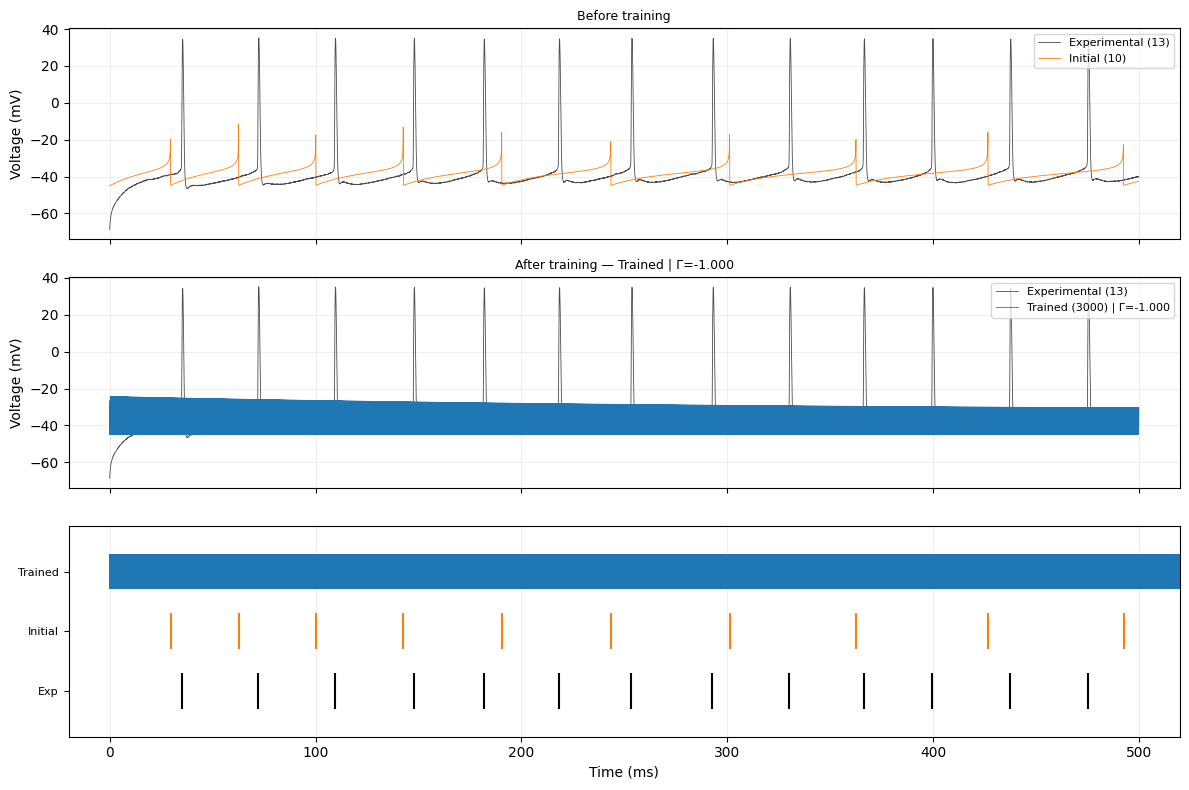

In [11]:
fit_before_after_plot(data, sim_init, sim_trained, coincidence=cf);

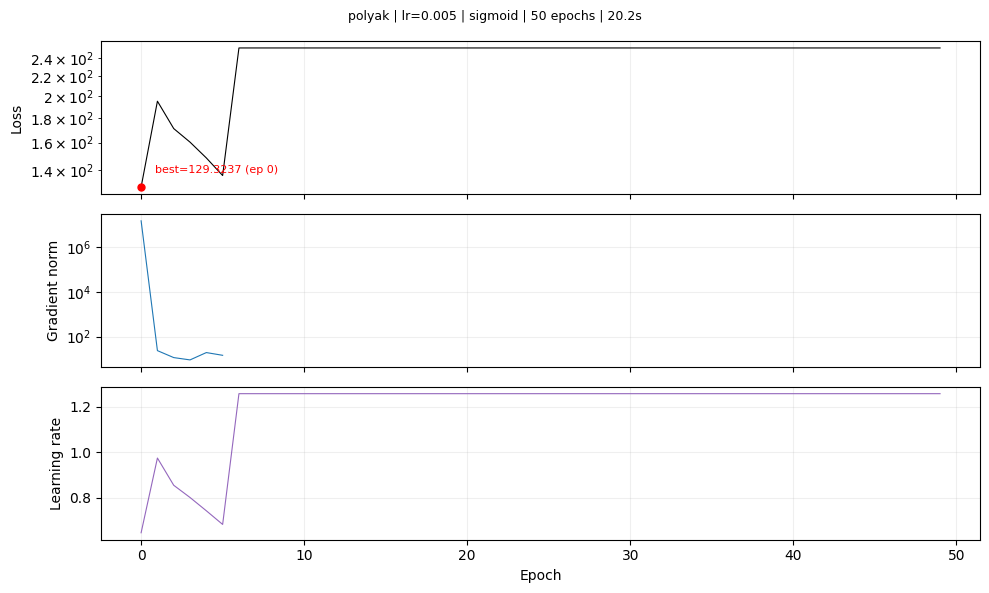

In [12]:
training_history_plot(result);

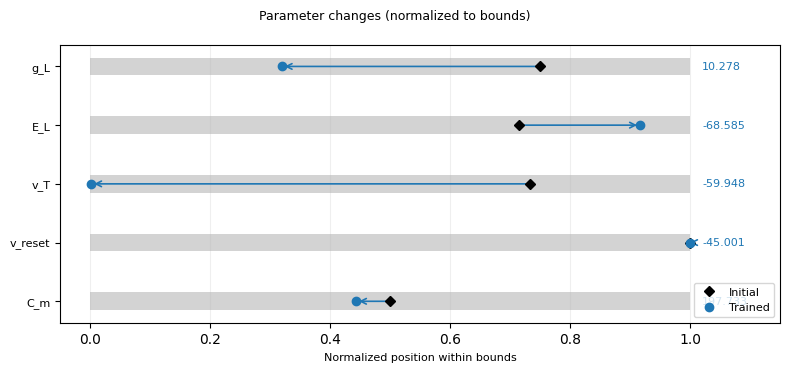

In [13]:
parameter_comparison_plot(result);

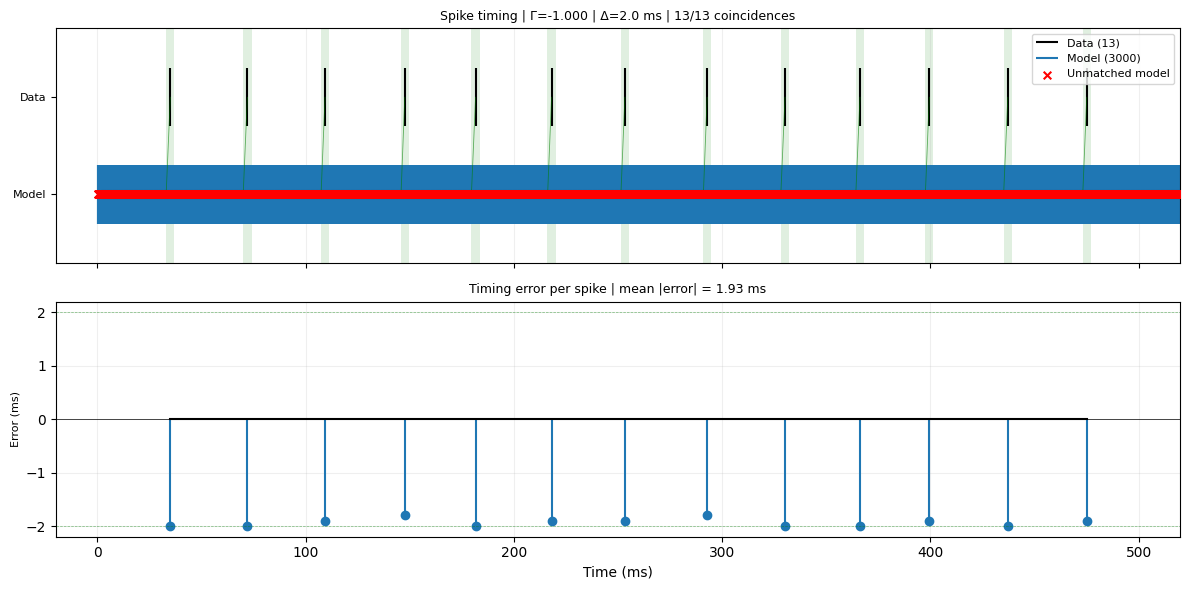

In [14]:
if cf is not None:
    spike_timing_plot(data, sim_trained, cf)
else:
    print("Spike timing plot skipped (no coincidence result)")